In [2]:
import numpy as np
from openxai.dataloader import ReturnLoaders
from openxai.model import LoadModel
from goodpoints import compress
import pandas as pd
import shap
np.seterr(all="warn")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [3]:
_, loader_test = ReturnLoaders(data_name="compas", download=False, batch_size=64)
X_test = loader_test.dataset.data

model = LoadModel(data_name="compas", ml_model="ann", pretrained=True)
model.eval()

/Users/milannapahasian_user_account/Documents/CTE_thesis/OpenXAI-main/openxai/model.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path+m

ArtificialNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=2, bias=True)
  )
)

In [4]:
predictions = model.predict(X_test)

In [5]:
n = X_test.shape[0]
d = X_test.shape[1]
sigma = np.sqrt(2 * d)

In [6]:
id_cte = compress.compresspp_kt(X_test, kernel_type=b"gaussian", k_params=np.array([sigma**2]), g=0, seed=0)
X_cte = X_test[id_cte]

In [7]:
X_test.shape

(1235, 7)

In [8]:
len(id_cte)

32

In [9]:
X_cte.shape

(32, 7)

testing "g"

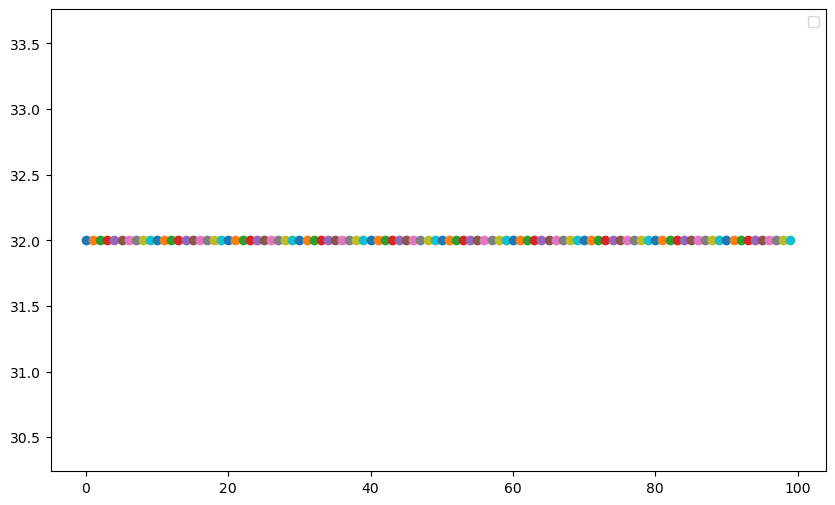

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for i in range(100):
    id_cte = compress.compresspp_kt(X_test, kernel_type=b"gaussian", k_params=np.array([sigma**2]), g=i, seed=0)
    plt.scatter(i, len(id_cte))

plt.legend()
plt.show()

testing "num_bins"

In [10]:
id_cte = compress.compresspp_kt(X_test, kernel_type=b"gaussian", k_params=np.array([sigma**2]), num_bins=1024, seed=0)

In [11]:
len(id_cte)

32

In [12]:
4**( (n.bit_length() - 1 )//2)

1024

can't make plot in range(100), kernel dies

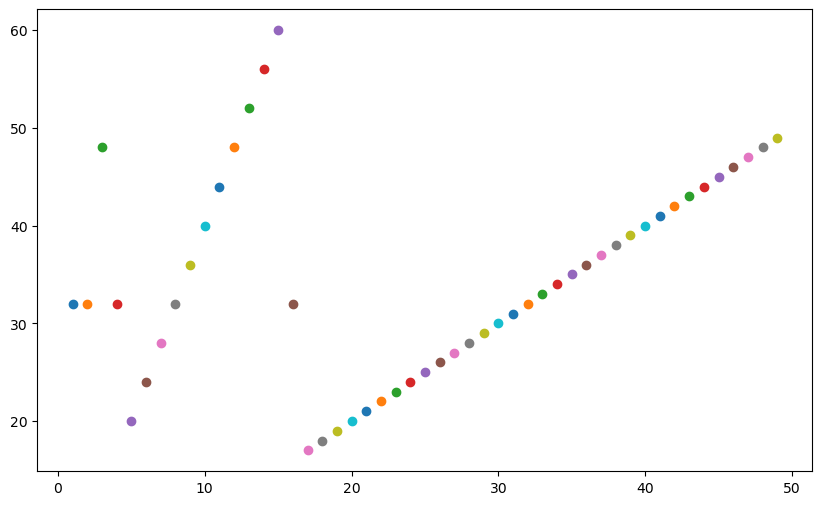

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(1, 50):
    try:
        id_cte = compress.compresspp_kt(X_test, kernel_type=b"gaussian", k_params=np.array([sigma**2]), num_bins=i, seed=0)
        plt.scatter(i, len(id_cte))
    except MemoryError:
        print(f"Memory error at i={i}, stopping early.")
        break
    except Exception as e:
        print(f"Error at i={i}: {e}")
        break 

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_9839/226051530.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


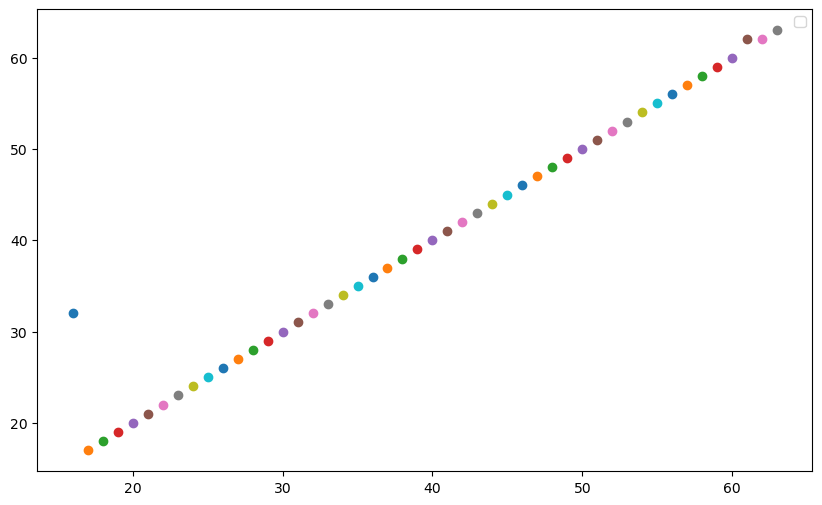

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for i in range(16,64):
    id_cte = compress.compresspp_kt(X_test, kernel_type=b"gaussian", k_params=np.array([sigma**2]), num_bins=i, seed=0)
    plt.scatter(i, len(id_cte))

plt.legend()
plt.show()

In [15]:
id_cte = compress.compresspp_kt(X_test, kernel_type=b"gaussian", k_params=np.array([sigma**2]), num_bins=17, seed=0)
len(id_cte)

17

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_9839/2445890705.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


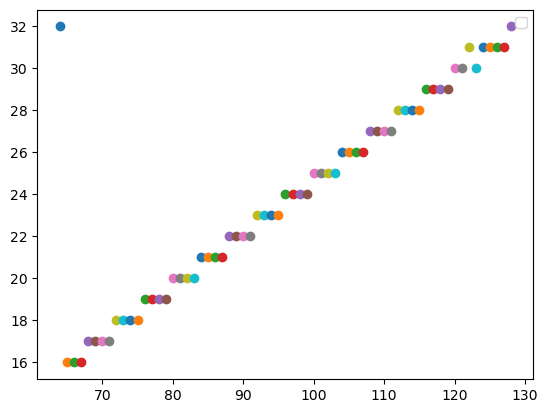

In [16]:
for i in range(64,129):
    id_cte = compress.compresspp_kt(X_test, kernel_type=b"gaussian", k_params=np.array([sigma**2]), num_bins=i, seed=0)
    plt.scatter(i, len(id_cte))

plt.legend()
plt.show()

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_9880/3814314082.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


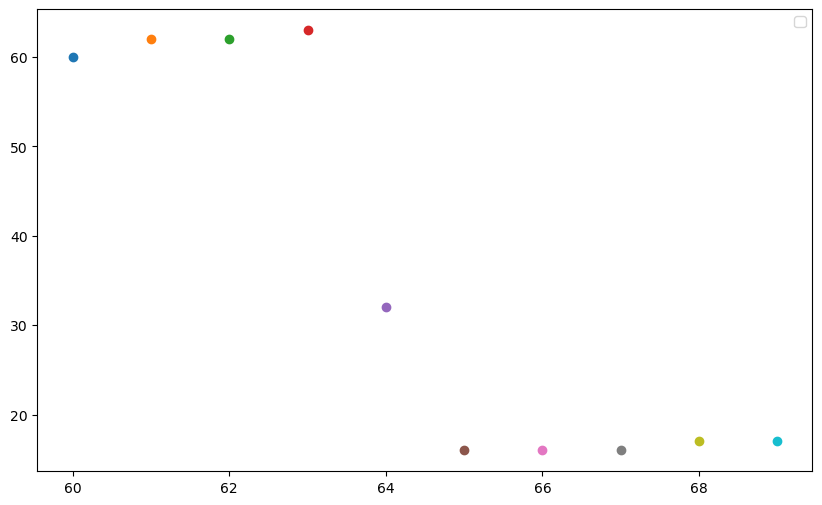

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for i in range(60,70):
    id_cte = compress.compresspp_kt(X_test, kernel_type=b"gaussian", k_params=np.array([sigma**2]), num_bins=i, seed=0)
    plt.scatter(i, len(id_cte))

plt.legend()
plt.show()

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_9880/1203574116.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


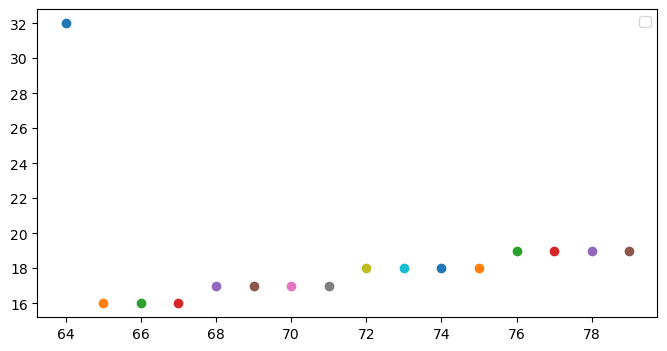

In [8]:
plt.figure(figsize=(8,4))
for i in range(64,80):
    id_cte = compress.compresspp_kt(X_test, kernel_type=b"gaussian", k_params=np.array([sigma**2]), num_bins=i, seed=0)
    plt.scatter(i, len(id_cte))

plt.legend()
plt.show()

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_9880/3107374874.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


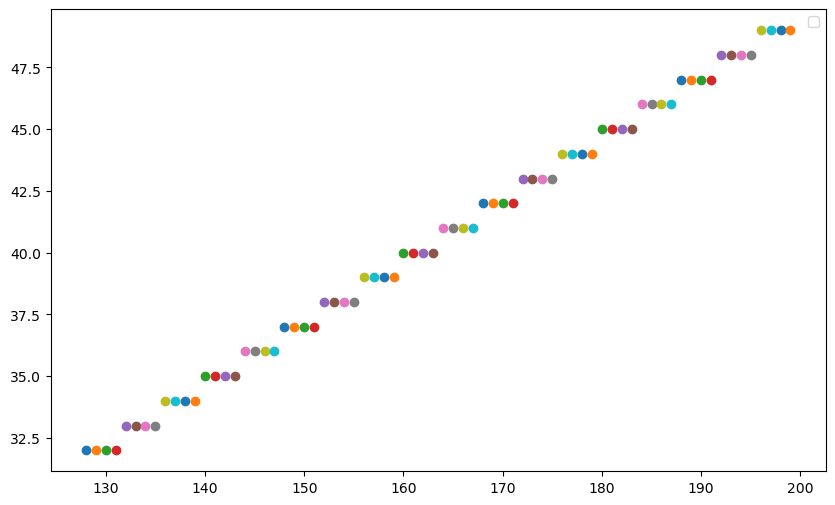

In [9]:
plt.figure(figsize=(10,6))
for i in range(128,200):
    id_cte = compress.compresspp_kt(X_test, kernel_type=b"gaussian", k_params=np.array([sigma**2]), num_bins=i, seed=0)
    plt.scatter(i, len(id_cte))

plt.legend()
plt.show()

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
for i in range(200,220):
    id_cte = compress.compresspp_kt(X_test, kernel_type=b"gaussian", k_params=np.array([sigma**2]), num_bins=i, seed=0)
    plt.scatter(i, len(id_cte))

plt.legend()
plt.show()

: 